# Jeu de traces simulées à partir d'un réseau

Ici on présente un exemple simple et complet avec une collection de traces simulées à partir d'un réseau.

Le réseau est un extrait de la BDTOPO située sur un versant de montagne en face de la ville de Chamonix.


In [1]:
import os
import sys

import matplotlib.pyplot as plt

# Import de tracklib
module_path = os.path.abspath(os.path.join('../../../../tracklib'))
if module_path not in sys.path:
    sys.path.append(module_path)

# Import de OFNP
module_path = os.path.abspath(os.path.join('../../..'))
if module_path not in sys.path:
    sys.path.append(module_path)

import tracklib as tkl

Number of edges= 10
Number of nodes= 9



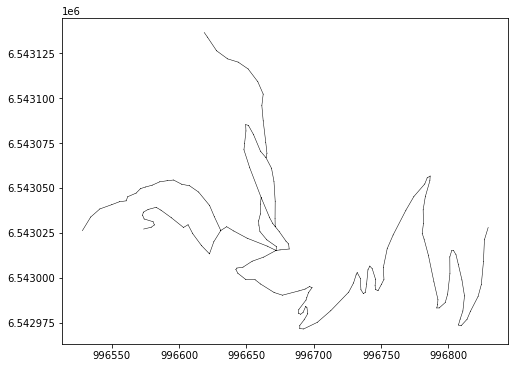

In [2]:
fmt = tkl.NetworkFormat({
       "pos_edge_id": 0,
       "pos_source": 1,
       "pos_target": 2,
       "pos_wkt": 4,
       "srid": "ENU",
       "separator": ",",
       "header": 1})
netpath = os.path.abspath(os.path.join('../../../data/network.txt'))
network = tkl.NetworkReader.readFromFile(netpath, fmt, verbose=False)

plt.figure(figsize=(8, 6))
network.plot('k-', '', 'g-', 'r-', 0.5, plt)

print ('Number of edges=', len(network.EDGES))
print ('Number of nodes=', len(network.NODES))
print ('')

100% (120 of 120) |######################| Elapsed Time: 0:00:02 Time:  0:00:020000


------------------------------------------------------------
105 (87.5 %) tracks generated on network
------------------------------------------------------------


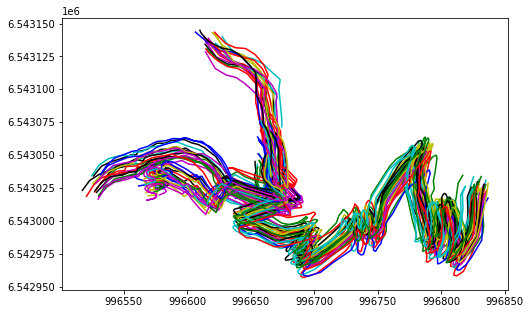

In [3]:
#
noiser = tkl.NoiseProcess(amps=5, kernels=tkl.ExponentialKernel(500))

# generate simulated trajectories from the network 
collection = tkl.generateTracksOnNetwork(network, N=120, p_round_trip=0.05, p_cplx_trip=0.10, resolution=1, noiser=noiser)

# add 3 attributes
for idx, track in enumerate(collection):
    track.createAnalyticalFeature('num', idx+1)
    track.createAnalyticalFeature('user_id', idx+1)
    track.createAnalyticalFeature('track_id', idx+1)
#
plt.figure(figsize=(8, 5))
collection.plot(append=plt)

## Dossier de stockage des résultats

In [4]:
from ofnp import setupenv

RESPATH = r'/home/md_vandamme/4_RESEAU/ZTEMP/'

setupenv(RESPATH)


## Step 1 : segment and resample

In [5]:
from ofnp import segmentation_resample

# Paramètre : Nombre de points minimum pour un morceau de trace au moment du découpage
#             si le nombre n'est pas atteint, le morceau de trace est oublié
NB_OBS_MIN           = 10

# Paramètre : Distance en mètres entre 2 points, si supérieure au seuil on coupe la trace
DIST_MAX_2OBS        = 50


RESAMPLE_SIZE_GRID = 1
RESAMPLE_SIZE_FUSION = 5

# =============================================================================
#  On définit un format pour le stockage des traces modifiées dans le pipeline
fmt = tkl.TrackFormat({'ext': 'CSV',
                           'srid': 'ENU',
                           'id_E': 1, 'id_N': 0, 'id_U': 3, 'id_T': 2,
                           'time_fmt': '2D/2M/4Y 2h:2m:2s',
                           'separator': ';',
                           'header': 0,
                           'cmt': '#',
                           'read_all': True})
segmentation_resample(RESPATH, collection, fmt, NB_OBS_MIN, DIST_MAX_2OBS,
                    RESAMPLE_SIZE_GRID, RESAMPLE_SIZE_FUSION)



Starting segmentation and resampling...
Starting segmentation ...
    Number of tracks after segmentation: 105
Finished saving segmented tracks.
Starting resampling ...
    Number of tracks to resample:  105
    Number of tracks after resampling: 105
    Number of tracks after resampling: 105
Finished saving resampled tracks.
Stage 1 finished: segmentation and resampling.


## Step 2 : calculs des cartes de densités, de constraste et binaire

In [6]:
from ofnp import density_polygonize

RESAMPLE_SIZE_GRID = 1

G1_SIZE = 2
G2_SIZE = 30 # 50

SEUIL_DENSITE = 300  # 15 - 1000
SEUIL_SURFACE = 1000 # m2 - 50000 - 7000

f = 2   # Cut factor

# =============================================================================
#
density_polygonize(RESPATH, G1_SIZE, G2_SIZE, SEUIL_DENSITE, SEUIL_SURFACE,
                       prefix='PT', rep='resample_grid', f=2)



 40% (43 of 105) |#########              | Elapsed Time: 0:00:00 ETA:   0:00:00

----------------------------------------------------------------------
STAGE 2 :                                   
   - Calcul d’une carte de densité à partir des traces GNSS 
   - De la vectorisation on extrait une ligne centrée ≡ arc de la topologie 
----------------------------------------------------------------------


100% (105 of 105) |######################| Elapsed Time: 0:00:00 Time:  0:00:000000


Number files to load:  105
Starting to compute aggregates ...
Temps d'exécution en s: 0.717177152633667
Fin des calculs des cartes de densités, de constraste et binaire.
Files '/home/md_vandamme/4_RESEAU/ZTEMP/image/erosion_PT.tif' and '/home/md_vandamme/4_RESEAU/ZTEMP/image/dilatation_PT.tif' deleted successfully.
Files road_surface.shp deleted successfully.
Files road_surface_lissee.shp deleted successfully.
Files surface.shp deleted successfully.
Files '/home/md_vandamme/4_RESEAU/ZTEMP/network/squelette_PT.shp' deleted successfully.


100% (1307 of 1307) |####################| Elapsed Time: 0:00:00 Time:  0:00:00
 62% (559 of 900) |#############         | Elapsed Time: 0:00:00 ETA:   0:00:00

Temps d'exécution en s: 0.23879313468933105
Fin de l'ouverture.
Temps d'exécution en s: 0.025398969650268555
Fin de la vectorisation.
une géométrie intérieure
une géométrie intérieure
une géométrie intérieure
une géométrie intérieure
une géométrie intérieure
Temps d'exécution en s: 0.09944963455200195
Fin du lissage de road surface.
*[2026-04-10 22:43:47.193675]  Importing polygons from: [/home/md_vandamme/4_RESEAU/ZTEMP/image/road_surface_lissee_PT.shp]... done

*[2026-04-10 22:43:47.227012]  Center line computation

*[2026-04-10 22:43:47.227181]  Upsampling polygon borders...

*[2026-04-10 22:43:47.252536]  Computing polygon skeleton...


100% (900 of 900) |######################| Elapsed Time: 0:00:00 Time:  0:00:00
100% (879 of 879) |######################| Elapsed Time: 0:00:00 Time:  0:00:00



*[2026-04-10 22:43:47.336462]  Filtering skeleton to form center line...

*[2026-04-10 22:43:47.350663]  Exporting center line to: [/home/md_vandamme/4_RESEAU/ZTEMP/network/squelette_PT.shp]... done
Temps d'exécution en s: 0.17035603523254395
Fin du calcul de la center line.
Fin des calculs de vectorisation et squelette.


<AxesSubplot:>

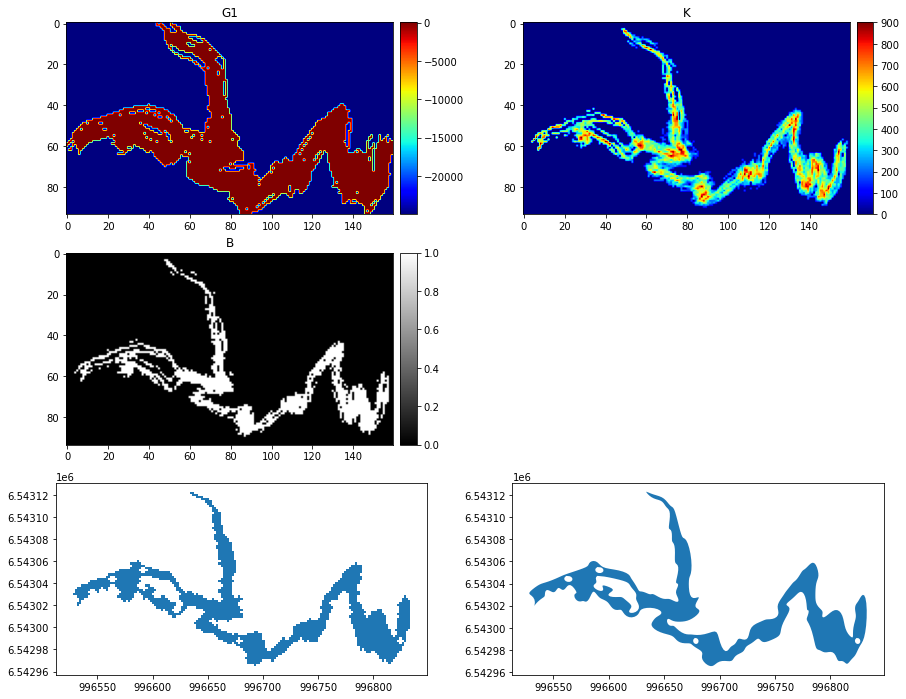

In [11]:
plt.figure(figsize=(15, 12))

ax1 = plt.subplot2grid((3, 2), (0, 0))
rasterG1 = tkl.RasterReader.readFromAscFile(RESPATH + 'image/G1_PT.asc', name='G1', separator='\t')
mapDensity = rasterG1.getAFMap('G1')
mapDensity.plotAsImage(cmap='jet', append=ax1)

ax2 = plt.subplot2grid((3, 2), (0, 1))
rasterK = tkl.RasterReader.readFromAscFile(RESPATH + 'image/K_PT.asc', name='K', separator='\t')
mapContraste = rasterK.getAFMap('K')
mapContraste.plotAsImage(cmap='jet', append=ax2)

ax3 = plt.subplot2grid((3, 2), (1, 0))
rasterB = tkl.RasterReader.readFromAscFile(RESPATH + 'image/B_PT.asc', name='B', separator='\t')
mapBinaire = rasterB.getAFMap('B')
mapBinaire.plotAsImage(append=ax3)

import geopandas as gpd
# charger le shapefile
gdf = gpd.read_file(RESPATH + 'image/road_surface_PT.shp')
ax5 = plt.subplot2grid((3, 2), (2, 0))
gdf.plot(ax=ax5)

ax6 = plt.subplot2grid((3, 2), (2, 1))
gdf = gpd.read_file(RESPATH + 'image/road_surface_lissee_PT.shp')
gdf.plot(ax=ax6)

In [8]:
from ofnp import network

DIST_MIN_ARC  = 50
network(RESPATH, DIST_MIN_ARC)

fmt = tkl.NetworkFormat({
           "pos_edge_id": 0,
           "pos_source": 1,
           "pos_target": 2,
           "pos_wkt": 4,
           "srid": "ENU",
           "separator": ",",
           "header": 1})
    
networkpath = RESPATH + 'network/reseau_PT.csv'
network = tkl.NetworkReader.readFromFile(networkpath, fmt, verbose=False)

Nb lignes :  311
Fin chargement des données 1/4.
Temps d'exécution en s: 0.10074543952941895
Fin construction du réseau 2/4.
Fin suppression des parties crochues du squelette 3/4.
    nb arcs supprimés:  17
    nb arcs supprimés:  9
Fin suppression des petis arcs 4/4.
Fin simplification 5/5.
Temps d'exécution en s: 0.09181380271911621
Fin construction et nettyage du squelette.
Fin de la construction du réseau.


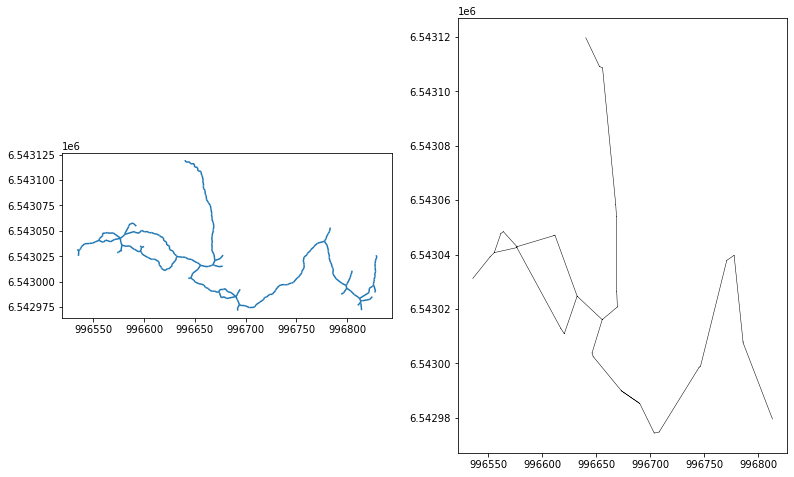

In [9]:
plt.figure(figsize=(13, 8))

ax1 = plt.subplot2grid((1, 2), (0, 0))
gdf = gpd.read_file(RESPATH + 'network/squelette_PT.shp')
gdf.plot(ax=ax1)

ax2 = plt.subplot2grid((1, 2), (0, 1))
network.plot('k-', '', 'g-', 'r-', 0.5, ax2)

In [10]:
from ofnp import createNetworkGeom

SEARCH = 25

createNetworkGeom(RESPATH, SEARCH, NB_OBS_MIN, DIST_MAX_2OBS)

100% (105 of 105) |######################| Elapsed Time: 0:00:00 Time:  0:00:000:00
100% (11 of 11) |########################| Elapsed Time: 0:00:00 Time:  0:00:00


--------------------------------------------------------------------------------------
 ETAPE 4 :                                                               
   - Attribue les points des traces brutes à chaque arc de la topologie 
   - Reconstruit les bons morceaux de traces candidats pour chaque arc de la topologie
   - Agrégation des morceaux de traces
   - Conflation des traces fusionnées afin d’obtenir un réseau de mobilité
--------------------------------------------------------------------------------------
--------------------------------------------------------------------------------------
Loading network ......
    Number of edges =  13
    Number of nodes =  11
 Longueur du réseau =  633.1457291690697
Loading collection of tracks ......
    Number of tracks: 105
Temps d'exécution en s: 0.17806005477905273
Map-matching preparation...
Launching Map-matching ...
Map-matching ended
Temps d'exécution en s: 0.31395864486694336
Map-matching results restructuring completed.


100% (100 of 100) |######################| Elapsed Time: 0:00:00 Time:  0:00:00
100% (100 of 100) |######################| Elapsed Time: 0:00:00 Time:  0:00:00
100% (100 of 100) |######################| Elapsed Time: 0:00:00 Time:  0:00:00
100% (100 of 100) |######################| Elapsed Time: 0:00:00 Time:  0:00:00
100% (100 of 100) |######################| Elapsed Time: 0:00:00 Time:  0:00:00
100% (100 of 100) |######################| Elapsed Time: 0:00:00 Time:  0:00:00
100% (100 of 100) |######################| Elapsed Time: 0:00:00 Time:  0:00:00
100% (100 of 100) |######################| Elapsed Time: 0:00:00 Time:  0:00:00
100% (100 of 100) |######################| Elapsed Time: 0:00:00 Time:  0:00:00
100% (100 of 100) |######################| Elapsed Time: 0:00:00 Time:  0:00:00
100% (100 of 100) |######################| Elapsed Time: 0:00:00 Time:  0:00:00
100% (100 of 100) |######################| Elapsed Time: 0:00:00 Time:  0:00:00
100% (100 of 100) |#####################

Mapmatched step completed
Temps d'exécution en s: 0.2917153835296631
Starting aggregation ...
Fusion pour le edge : 559
    Nombre de traces à fusionner (avant le tirage): 37
    Number of candidates in the aggregation process: 30
Launching Aggregation ......
[2026-04-10 22:43:49.368922]   ITERATION 0
CV =  4.427797657263
[2026-04-10 22:43:49.374366]   ITERATION 1
CV =  0.0
[2026-04-10 22:43:49.380098]    COMPUTATION DONE IN 0:00:00.011308
[2026-04-10 22:43:49.380323]   ITERATION 0
CV =  12.13036352019224
[2026-04-10 22:43:49.386284]   ITERATION 1
CV =  0.16679624025709927
[2026-04-10 22:43:49.392002]   ITERATION 2
CV =  0.0
[2026-04-10 22:43:49.398645]    COMPUTATION DONE IN 0:00:00.018526
[2026-04-10 22:43:49.398857]   ITERATION 0
CV =  0.973464371514128
[2026-04-10 22:43:49.407426]   ITERATION 1
CV =  0.0
[2026-04-10 22:43:49.413525]    COMPUTATION DONE IN 0:00:00.014856
[2026-04-10 22:43:49.413746]   ITERATION 0
CV =  7.060287803643591
[2026-04-10 22:43:49.424019]   ITERATION 1
CV 

100% (100 of 100) |######################| Elapsed Time: 0:00:00 Time:  0:00:00
100% (100 of 100) |######################| Elapsed Time: 0:00:00 Time:  0:00:00
100% (100 of 100) |######################| Elapsed Time: 0:00:00 Time:  0:00:00
100% (100 of 100) |######################| Elapsed Time: 0:00:00 Time:  0:00:00
100% (100 of 100) |######################| Elapsed Time: 0:00:00 Time:  0:00:00
100% (100 of 100) |######################| Elapsed Time: 0:00:00 Time:  0:00:00
100% (100 of 100) |######################| Elapsed Time: 0:00:00 Time:  0:00:00
100% (100 of 100) |######################| Elapsed Time: 0:00:00 Time:  0:00:00
100% (100 of 100) |######################| Elapsed Time: 0:00:00 Time:  0:00:00
100% (100 of 100) |######################| Elapsed Time: 0:00:00 Time:  0:00:00
100% (100 of 100) |######################| Elapsed Time: 0:00:00 Time:  0:00:00
100% (100 of 100) |######################| Elapsed Time: 0:00:00 Time:  0:00:00
100% (100 of 100) |#####################

...

CV =  0.2700361630396635
[2026-04-10 22:43:51.127796]   ITERATION 4
CV =  0.013028611103072763
[2026-04-10 22:43:51.196532]   ITERATION 5
CV =  0.0
[2026-04-10 22:43:51.238329]    COMPUTATION DONE IN 0:00:00.292573
Aggregation ended
Fusion pour le edge : 511
    Nombre de traces à fusionner (avant le tirage): 26
    Number of candidates in the aggregation process: 26
Launching Aggregation ......
[2026-04-10 22:43:51.247495]   ITERATION 0
CV =  5.759115061672668
[2026-04-10 22:43:51.252166]   ITERATION 1
CV =  1.4989519530360127
[2026-04-10 22:43:51.256420]   ITERATION 2
CV =  0.0
[2026-04-10 22:43:51.260451]    COMPUTATION DONE IN 0:00:00.013134
[2026-04-10 22:43:51.260616]   ITERATION 0
CV =  4.7153968214597715
[2026-04-10 22:43:51.264492]   ITERATION 1
CV =  0.0
[2026-04-10 22:43:51.268190]    COMPUTATION DONE IN 0:00:00.007720
[2026-04-10 22:43:51.268466]   ITERATION 0
CV =  2.726855681395982
[2026-04-10 22:43:51.272670]   ITERATION 1
CV =  0.5731488681927251
[2026-04-10 22:43:51.27

100% (100 of 100) |######################| Elapsed Time: 0:00:00 Time:  0:00:00
100% (100 of 100) |######################| Elapsed Time: 0:00:00 Time:  0:00:00
100% (100 of 100) |######################| Elapsed Time: 0:00:00 Time:  0:00:00
100% (100 of 100) |######################| Elapsed Time: 0:00:00 Time:  0:00:00
100% (100 of 100) |######################| Elapsed Time: 0:00:00 Time:  0:00:00
100% (100 of 100) |######################| Elapsed Time: 0:00:00 Time:  0:00:00
100% (100 of 100) |######################| Elapsed Time: 0:00:00 Time:  0:00:00
100% (100 of 100) |######################| Elapsed Time: 0:00:00 Time:  0:00:00
100% (100 of 100) |######################| Elapsed Time: 0:00:00 Time:  0:00:00
100% (100 of 100) |######################| Elapsed Time: 0:00:00 Time:  0:00:00
100% (100 of 100) |######################| Elapsed Time: 0:00:00 Time:  0:00:00
100% (100 of 100) |######################| Elapsed Time: 0:00:00 Time:  0:00:00
100% (100 of 100) |#####################

CV =  6.606190439980507
[2026-04-10 22:43:51.334450]   ITERATION 1
CV =  0.0
[2026-04-10 22:43:51.337604]    COMPUTATION DONE IN 0:00:00.006487
[2026-04-10 22:43:51.337798]   ITERATION 0
CV =  7.269050949247637
[2026-04-10 22:43:51.349958]   ITERATION 1
CV =  2.144272378540682
[2026-04-10 22:43:51.362435]   ITERATION 2
CV =  0.5991174754453823
[2026-04-10 22:43:51.374258]   ITERATION 3
CV =  0.0
[2026-04-10 22:43:51.386537]    COMPUTATION DONE IN 0:00:00.048914
[2026-04-10 22:43:51.386726]   ITERATION 0
CV =  1.2938270948077428
[2026-04-10 22:43:51.401619]   ITERATION 1
CV =  0.0
[2026-04-10 22:43:51.418838]    COMPUTATION DONE IN 0:00:00.032283
Aggregation ended
Fusion pour le edge : 503
    Nombre de traces à fusionner (avant le tirage): 8
    Number of candidates in the aggregation process: 8
Launching Aggregation ......
[2026-04-10 22:43:51.442612]   ITERATION 0
CV =  1.1603182137904298
[2026-04-10 22:43:51.462821]   ITERATION 1
CV =  0.15994922467507422
[2026-04-10 22:43:51.480382

100% (100 of 100) |######################| Elapsed Time: 0:00:00 Time:  0:00:00
100% (100 of 100) |######################| Elapsed Time: 0:00:00 Time:  0:00:00
100% (100 of 100) |######################| Elapsed Time: 0:00:00 Time:  0:00:00
100% (100 of 100) |######################| Elapsed Time: 0:00:00 Time:  0:00:00
100% (100 of 100) |######################| Elapsed Time: 0:00:00 Time:  0:00:00
100% (100 of 100) |######################| Elapsed Time: 0:00:00 Time:  0:00:00
100% (100 of 100) |######################| Elapsed Time: 0:00:00 Time:  0:00:00
100% (100 of 100) |######################| Elapsed Time: 0:00:00 Time:  0:00:00
100% (100 of 100) |######################| Elapsed Time: 0:00:00 Time:  0:00:00
100% (100 of 100) |######################| Elapsed Time: 0:00:00 Time:  0:00:00
100% (100 of 100) |######################| Elapsed Time: 0:00:00 Time:  0:00:00
100% (100 of 100) |######################| Elapsed Time: 0:00:00 Time:  0:00:00
100% (100 of 100) |#####################

CV =  0.0
[2026-04-10 22:43:51.536463]    COMPUTATION DONE IN 0:00:00.032992
Aggregation ended
Dernière fusion pour le edge : 412
    Nombre de traces à fusionner (avant le tirage): 14
    Number of candidates in the aggregation process: 14
Launching Aggregation ......
[2026-04-10 22:43:51.540978]   ITERATION 0
CV =  0.0
[2026-04-10 22:43:51.543648]    COMPUTATION DONE IN 0:00:00.002926
[2026-04-10 22:43:51.543801]   ITERATION 0
CV =  0.0
[2026-04-10 22:43:51.545682]    COMPUTATION DONE IN 0:00:00.002015
[2026-04-10 22:43:51.545868]   ITERATION 0
CV =  0.0
[2026-04-10 22:43:51.548007]    COMPUTATION DONE IN 0:00:00.002306
[2026-04-10 22:43:51.548188]   ITERATION 0
CV =  0.0
[2026-04-10 22:43:51.550127]    COMPUTATION DONE IN 0:00:00.002100
[2026-04-10 22:43:51.550307]   ITERATION 0
CV =  0.0
[2026-04-10 22:43:51.552544]    COMPUTATION DONE IN 0:00:00.002399
[2026-04-10 22:43:51.552709]   ITERATION 0
CV =  0.0
[2026-04-10 22:43:51.554799]    COMPUTATION DONE IN 0:00:00.002236
[2026-04-1